# Transformaciones a Tiempo-Frecuencia (Espacial)

In [1]:
# Cargar los datos acondicionados
from os import path
import pandas as pd

FILE_PATH = './data/eeg_eye_state_clean.csv'

if not path.exists(FILE_PATH):
    print("El archivo no existe.")
    raise FileNotFoundError(f"El archivo no existe: {FILE_PATH}")
else:
    df = pd.read_csv(FILE_PATH)
    print(f"Los datos ya existen en {FILE_PATH}")

Los datos ya existen en ./data/eeg_eye_state_clean.csv


In [2]:
FS = 128  # Frecuencia de muestreo en Hz
CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
TARGET_COL = 'eyeDetection' # 0: ojos abiertos, 1: ojos cerrados
display(df.head())

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_sec
0,0.316971,-0.009932,-0.425399,-0.178523,-0.494695,-0.433637,-0.376319,-0.087012,-0.367599,-0.179203,-0.065061,-0.206498,0.295136,0.311536,0,0.000000
1,0.148518,-0.261323,-0.037807,0.000146,-1.887244,-0.401899,-0.310983,-0.504367,-1.656623,-1.487171,-0.371773,-0.286736,0.059742,-0.096744,0,0.007812
2,0.238763,-0.152552,0.258011,0.428687,-2.286898,-0.829564,-0.284813,-0.935728,-1.394720,-1.576502,-0.374950,0.011409,-0.002535,0.073527,0,0.015625
3,0.364411,0.140839,0.320441,0.498201,-1.508022,-0.950506,-0.305047,-1.126591,-0.857133,-0.378787,-0.068891,0.567911,0.115806,0.539387,0,0.023438
4,0.223380,0.102305,-0.028270,0.257180,-0.774204,-0.464788,-0.393875,-1.558265,-1.449961,0.302875,0.184332,0.703156,0.188856,0.642532,0,0.031250


## GSP

Las técnicas STFT y CWT analizan cada canal EEG de forma **independiente**:
toman una señal 1D y la descomponen en tiempo y frecuencia. Sin embargo, el
cerebro es un sistema distribuido — la actividad eléctrica no ocurre de forma
aislada en cada electrodo, sino en **patrones coordinados entre regiones**.
La pregunta que surge naturalmente es: ¿cómo representar esa estructura espacial?

El **Graph Signal Processing (GSP)** responde esta pregunta tratando los
electrodos como nodos de una red (grafo) y generalizando el análisis espectral
a esa estructura.

---

#### 1. Grafo de conectividad

Primero se necesita definir *cómo están conectados* los electrodos. En lugar
de usar distancias físicas en el cuero cabelludo, se usa el algoritmo de
**Kalofolias**, que *aprende* los pesos de las conexiones directamente
desde los datos: dos electrodos tendrán una arista de mayor peso si sus señales
son estadísticamente similares a lo largo del registro.

El resultado es una **matriz de adyacencia** $W$ de dimensión $14 \times 14$,
donde $W_{i,j}$ indica cuán fuertemente conectados están los electrodos $i$ y
$j$ según la actividad EEG.

---

#### 2. Laplaciano del grafo y su descomposición

A partir de $W$ se construye el **Laplaciano** $L = D - W$, donde $D$ es la
matriz de grado (diagonal con la suma de pesos de cada nodo). El Laplaciano
codifica la estructura topológica del grafo y es el equivalente en grafos del
operador diferencial de la Fourier clásica.

Su descomposición espectral es:

$$L = U \Lambda U^\top$$

donde:

- $U \in \mathbb{R}^{14 \times 14}$: matriz de **autovectores**, cuyos columnas
  son los **modos espaciales** del grafo. Cada columna de $U$ es un patrón de
  activación distribuida sobre los 14 electrodos.
- $\Lambda$: matriz diagonal de **autovalores**
  $\lambda_0 \leq \lambda_1 \leq \cdots \leq \lambda_{13}$, que indican la
  **suavidad espacial** de cada modo:
  - $\lambda_0 \approx 0$ → modo más suave: todos los electrodos activos de
    forma similar (componente de modo común, análogo al DC en Fourier).
  - $\lambda_{13}$ grande → modo más oscilatorio: electrodos vecinos con
    actividad muy distinta (análogo a la alta frecuencia en Fourier).

---

#### 3. GFT y el espectrograma de grafo

La **Transformada de Fourier del Grafo** proyecta la señal EEG sobre la base
de modos espaciales:

$$\hat{x}(t) = U^\top \, x(t)$$

donde $x(t) \in \mathbb{R}^{14}$ es el vector de los 14 canales en el instante
$t$. El resultado $\hat{x}(t) \in \mathbb{R}^{14}$ indica **cuánto de cada modo
espacial está presente en ese instante**.

Al calcular $\left|\hat{x}(t)\right|^2$ para todos los instantes de tiempo se
obtiene el **espectrograma de grafo**: una matriz de $14\ \text{modos} \times N\
\text{instantes}$ que muestra cómo evoluciona la energía de cada patrón espacial
a lo largo del tiempo.

---

#### ¿Qué se puede leer en el espectrograma de grafo?

| Eje / elemento | Significado |
|---|---|
| Eje X | Tiempo (igual que en STFT/CWT) |
| Eje Y | Modos espaciales $\lambda_0 \ldots \lambda_{13}$ **(NO son Hz)** |
| Color | Energía del modo $k$ en el instante $t$ (dB) |

Si durante los períodos de **ojos cerrados** se observa mayor energía en un
modo particular, eso significa que ese *patrón espacial de activación* es
característico de ese estado. Fisiológicamente, el ritmo alfa en reposo con
ojos cerrados involucra actividad occipital sincronizada — lo que
correspondería a un modo de baja frecuencia de grafo ($\lambda$ pequeño) con
carga alta en los electrodos O1 y O2.

---

#### Diferencia fundamental con STFT y CWT

|  | STFT / CWT | GFT |
|---|---|---|
| Dominio de análisis | Frecuencia temporal (Hz) | Frecuencia espacial ($\lambda$) |
| Unidad del eje Y | Hz | Autovalores del Laplaciano |
| Canal analizado | Uno a la vez | Los 14 simultáneamente |
| Captura sincronía inter-canal | No directamente | Sí |

Por esta razón, el GSP **no es una técnica TF en el sentido clásico** y no
puede compararse directamente con STFT y CWT en las mismas métricas. Se
presenta como una representación **complementaria** que captura la dimensión
espacial de la actividad EEG, inaccesible mediante los métodos anteriores.

In [3]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from eegrasp import EEGrasp
import scipy.ndimage

Found solution after 238 iterations
Found solution after 238 iterations
GSP — Espectrograma: (14, 14980)  (modos x tiempo)
Autovalores: [0.    0.028 0.107 0.199 0.327 0.446 0.482 0.7   0.858 0.904 1.022 1.098
 1.156 1.359]


/tmp/ipykernel_110890/4259402339.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


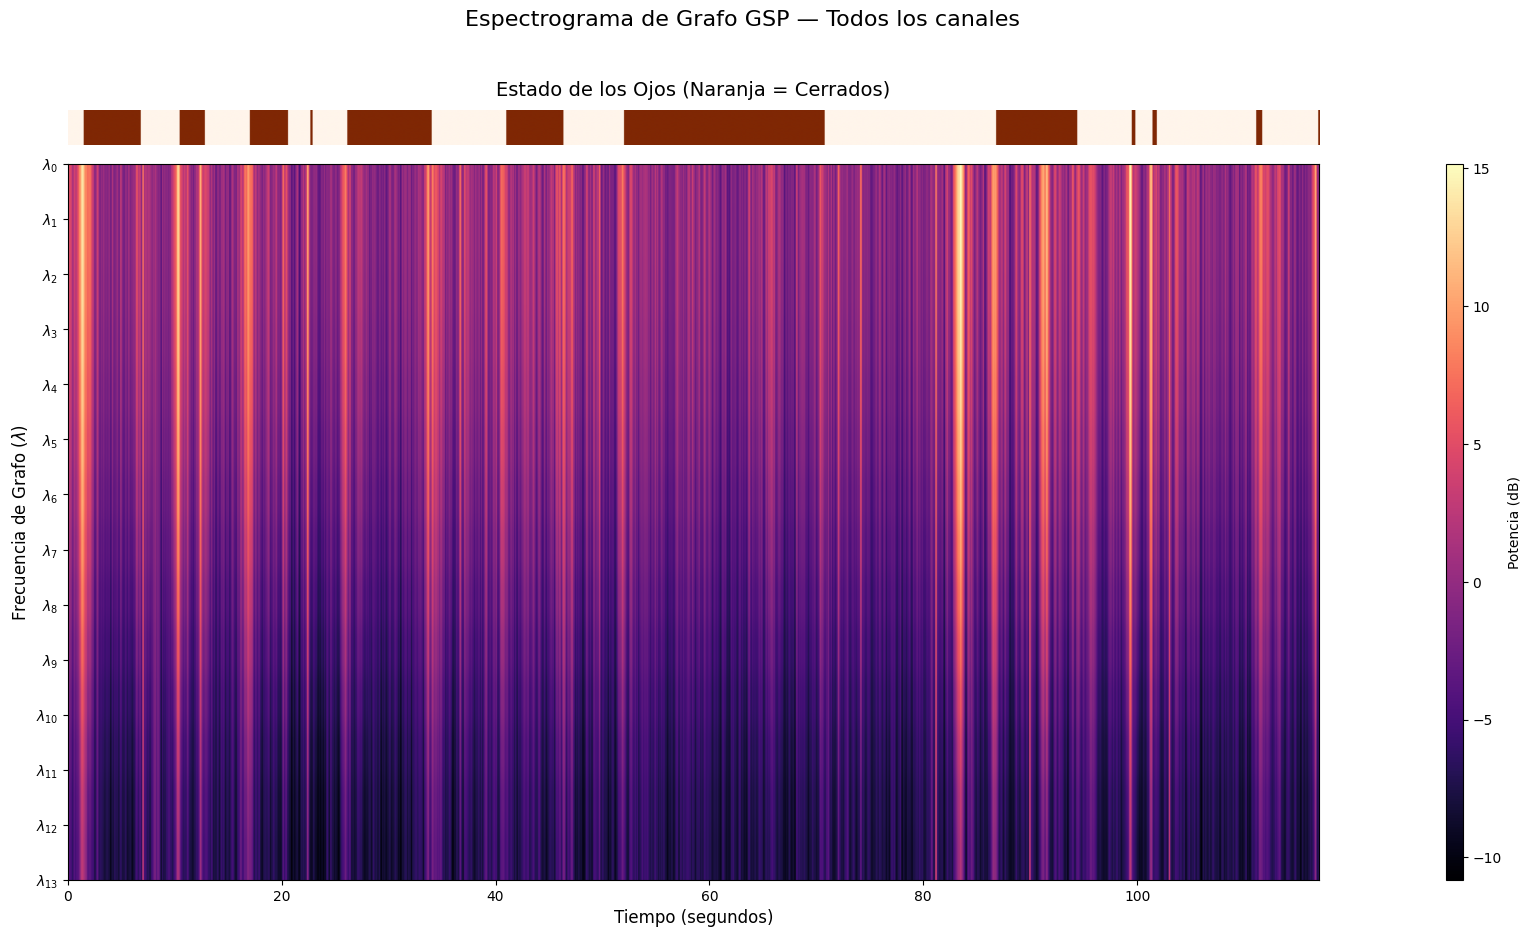

In [4]:
# ── 1. Posiciones 3D de los electrodos (montaje estándar 10-20) ────────────
# Se necesitan las coordenadas 3D para que EEGrasp pueda usar la geometría
# del cuero cabelludo como información auxiliar al aprender el grafo.
base_montage = mne.channels.make_standard_montage('standard_1020')
eeg_pos_dict = base_montage.get_positions()['ch_pos']
eeg_pos      = np.array([eeg_pos_dict[ch] for ch in CHANNELS])  # (14, 3)

# ── 2. Construir Grafo Aprendido (Kalofolias) ──────────────────────────────
# learn_graph infiere los pesos W[i,j] desde la similitud estadística entre
# canales. Los parámetros a y b controlan suavidad y dispersidad del grafo.
eeg_data = df[CHANNELS].values.T   # (14, N): canales × muestras
gsp      = EEGrasp(coordinates=eeg_pos, labels=CHANNELS)
gsp.data = eeg_data
W, _     = gsp.learn_graph(a=0.34, b=0.4)
G        = gsp.compute_graph(W)

# ── 3. Base de Fourier del Grafo ───────────────────────────────────────────
# El Laplaciano L = D - W codifica la topología del grafo.
# Su descomposición L = U Λ Uᵀ produce:
#   U     → modos espaciales (patrones de activación entre electrodos)
#   evals → autovalores λ (suavidad espacial de cada modo)
G.set_coordinates(eeg_pos)
G.compute_laplacian()
G.compute_fourier_basis()
evals = np.array(G.e)   # autovalores  shape: (14,)
U     = np.array(G.U)   # autovectores shape: (14, 14)

# ── 4. GFT ventana a ventana → Espectrograma de Grafo ─────────────────────
# x_hat[k, t] = energía del modo k en el instante t
# Se descompone el vector de 14 canales en los 14 modos espaciales. 
# NO hay ventaneo temporal, la proyección es una operación matricial instantánea aplicada sample a sample.
x_hat = U.T @ eeg_data                    # shape: (14, N)
graph_spectrogram = x_hat ** 2            # potencia por modo y tiempo

# Suavizado gaussiano para mejor visualización
graph_spectrogram_smooth = scipy.ndimage.gaussian_filter(graph_spectrogram, sigma=5)
graph_spectrogram_log    = 10 * np.log10(graph_spectrogram_smooth + 1e-6)

# Eje temporal y extent para imshow
n_muestras   = eeg_data.shape[1]
tiempo_total = n_muestras / FS
times_gsp    = np.linspace(0, tiempo_total, n_muestras)
extent       = [0, tiempo_total, len(evals) - 1, 0]

# Labels alineadas al eje temporal completo
labels_gsp = df[TARGET_COL].values        # shape: (N,)

print(f"GSP — Espectrograma: {graph_spectrogram_log.shape}  (modos x tiempo)")
print(f"Autovalores: {evals.round(3)}")

# ── 5. Visualización ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, height_ratios=[0.05, 1],
                         width_ratios=[1.5, 0.02], hspace=0.05)

ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(labels_gsp[np.newaxis, :], aspect='auto', cmap='Oranges',
           extent=[0, tiempo_total, 0, 1])
ax0.set_axis_off()
ax0.set_title('Estado de los Ojos (Naranja = Cerrados)', fontsize=14, pad=10)

ax1 = fig.add_subplot(gs[1, 0])
im  = ax1.imshow(graph_spectrogram_log, aspect='auto', cmap='magma', extent=extent)
ax1.set_xlabel('Tiempo (segundos)', fontsize=12)
ax1.set_ylabel('Frecuencia de Grafo ($\\lambda$)', fontsize=12)
ax1.set_yticks(range(len(evals)))
ax1.set_yticklabels([f'$\\lambda_{{{i}}}$' for i in range(len(evals))])

cbar_ax = fig.add_subplot(gs[1, 1])
fig.colorbar(im, cax=cbar_ax, label='Potencia (dB)')
plt.suptitle('Espectrograma de Grafo GSP — Todos los canales', fontsize=16)
plt.tight_layout()
plt.show()

## TSP

Mientras que el GSP analiza las señales en los electrodos (nodos) basándose en conexiones par a par, el **Topological Signal Processing (TSP)** extiende este análisis hacia interacciones de **orden superior**. En el cerebro, los procesos cognitivos y los estados de sincronización complejos —como el paso de ojos abiertos a ojos cerrados— no solo involucran a dos regiones conectadas, sino a **grupos de regiones actuando coordinadamente en redes cerradas (ciclos y triángulos)**.

El TSP responde a esto modelando el EEG mediante un **complejo simplicial** en lugar de un grafo simple, generalizando el análisis espectral a los flujos y relaciones estructurales de orden superior.

---

#### 1. Del Grafo al Complejo Simplicial

Utilizando la matriz de adyacencia aprendida por Kalofolias, se aplica un umbral adaptativo (percentil 30%) para binarizar el grafo y conservar únicamente las conexiones funcionales dominantes. A partir de esta estructura binaria, el TSP identifica:

* **Nodos (0-símplices):** Los 14 electrodos individuales ($V=14$).
* **Aristas (1-símplices):** Las conexiones fuertes que superaron el umbral ($E=16$).
* **Triángulos (2-símplices):** Estructuras cerradas de 3 nodos totalmente conectados entre sí ($T=1$). Estos representan los "acordes" de sincronización grupal simultánea.

---

#### 2. Laplaciano de Hodge y su Descomposición

Para codificar la topología de orden superior, se construyen las matrices de incidencia orientadas $B_1$ (Nodos a Aristas, dimensión $14 \times 16$) y $B_2$ (Aristas a Triángulos, dimensión $16 \times 1$). En lugar del Laplaciano convencional, se calcula el **Laplaciano de Hodge de orden 1 ($L_1$)**:

$$L_1 = B_1^\top B_1 + B_2 B_2^\top$$

La matriz $L_1$ (dimensión $16 \times 16$) codifica cómo fluye la información a través de las aristas. El término $B_1^\top B_1$ representa los flujos inducidos por los nodos (gradientes), mientras que $B_2 B_2^\top$ captura las dinámicas circulares o rotacionales permitidas por los triángulos.

Su descomposición espectral es:

$$L_1 = U_1 \Lambda_1 U_1^\top$$

donde:

* $U_1 \in \mathbb{R}^{16 \times 16}$: matriz de **autovectores**, cuyas columnas definen los **modos topológicos de arista**. Cada columna representa un patrón de flujo o co-activación a través de las conexiones de la red.
* $\Lambda_1$: matriz diagonal de **autovalores** (frecuencias topológicas), que ordenan los modos según su variación o suavidad a lo largo de la estructura del complejo simplicial.

---

#### 3. TFT y el Espectrograma Topológico

Dado que los autovectores de $U_1$ operan en el dominio de las aristas, la señal original del EEG en los nodos ($x(t) \in \mathbb{R}^{14}$) se proyecta primero a las aristas mediante el operador gradiente: $y(t) = B_1^\top x(t)$.

La **Transformada de Fourier Topológica (TFT)** proyecta este flujo inter-canal sobre la base de modos topológicos:

$$\hat{y}(t) = U_1^\top y(t)$$

Al calcular $\left|\hat{y}(t)\right|^2$ para todos los instantes, se obtiene el **espectrograma topológico**: una matriz de $18\ \text{modos de arista} \times N\ \text{instantes}$. Esta matriz describe cómo evoluciona la energía y la sincronización grupal del flujo cerebral en el tiempo, aislando de forma directa la actividad asociada a los estados de ojos abiertos y cerrados desde una perspectiva puramente estructural.

---

#### Diferencia conceptual: GSP vs TSP

| Métrica | GSP | TSP ($L_1$) |
| --- | --- | --- |
| **Dominio de la Señal** | Nodos (Electrodos individuales) | Aristas (Flujo/Conexiones entre electrodos) |
| **Estructura Base** | Grafo simple (Vértices y Aristas) | Complejo Simplicial (Vértices, Aristas y Triángulos) |
| **Interacciones** | Locales y par a par (Canal A $\leftrightarrow$ Canal B) | Colectivas de orden superior (Ciclos y Grupos) |
| **Operador Espectral** | Laplaciano de Grafo ($L$) | Laplaciano de Hodge ($L_1$) |

In [5]:
# --- Celda 1: Construcción del Complejo Simplicial ---
import networkx as nx
import numpy as np
import scipy.sparse

# 1. Binarizar el grafo aprendido por Kalofolias
# Convertir W a matriz densa si es sparse (depende de cómo lo retorne EEGrasp)
W_dense = W.toarray() if scipy.sparse.issparse(W) else np.array(W)

# Usaremos un umbral (ej. el top 70% de los pesos más fuertes) para definir las aristas
threshold = np.percentile(W_dense[W_dense > 0], 30)
A_bin = (W_dense >= threshold).astype(int)
np.fill_diagonal(A_bin, 0) # Remover auto-bucles por sanidad topológica

# 2. Crear el grafo para extraer la estructura
G_nx = nx.from_numpy_array(A_bin)
V = G_nx.number_of_nodes()

# Extraer Aristas (1-símplices)
edges = list(G_nx.edges())
E = len(edges)

# Extraer Triángulos (2-símplices) usando búsqueda de cliques
cliques = list(nx.enumerate_all_cliques(G_nx))
triangles = [c for c in cliques if len(c) == 3]
T = len(triangles)

print(f"Topología extraída:")
print(f"Nodos (V): {V} (Debe ser 14)")
print(f"Aristas (E): {E} (Conexiones fuertes)")
print(f"Triángulos (T): {T} (Sincronización de 3 canales)\n")

for idx, tri in enumerate(triangles):
    # tri contiene los índices de los 3 canales, por ejemplo: [6, 7, 9]
    canales_involucrados = [CHANNELS[i] for i in tri]
    
    print(f"Triángulo {idx + 1}:")
    print(f"  • Índices en la matriz: {tri}")
    print(f"  • Electrodos activados en grupo: {', '.join(canales_involucrados)}")
    print("-" * 50)

Topología extraída:
Nodos (V): 14 (Debe ser 14)
Aristas (E): 16 (Conexiones fuertes)
Triángulos (T): 1 (Sincronización de 3 canales)

Triángulo 1:
  • Índices en la matriz: [7, 8, 9]
  • Electrodos activados en grupo: O2, P8, T8
--------------------------------------------------


In [6]:
# --- Celda 2: Laplaciano de Hodge (L1) ---

# 3. Construir B1 (Nodos a Aristas)
B1 = np.zeros((V, E))
for idx_e, (u, v) in enumerate(edges):
    # Orientación: del nodo con menor índice al mayor
    B1[u, idx_e] = -1
    B1[v, idx_e] = 1

# 4. Construir B2 (Aristas a Triángulos)
B2 = np.zeros((E, T))
edge_to_idx = {edge: i for i, edge in enumerate(edges)}

def get_edge_idx(u, v):
    # Busca la arista sin importar el orden en que fue guardada
    return edge_to_idx.get((u, v), edge_to_idx.get((v, u)))

for idx_t, tri in enumerate(triangles):
    u, v, w = sorted(tri) 
    # Las 3 fronteras del triángulo [u,v,w]
    e_uv = get_edge_idx(u, v)
    e_vw = get_edge_idx(v, w)
    e_uw = get_edge_idx(u, w)
    
    # Orientación estándar de la frontera del triángulo
    if e_uv is not None: B2[e_uv, idx_t] = 1
    if e_vw is not None: B2[e_vw, idx_t] = 1
    if e_uw is not None: B2[e_uw, idx_t] = -1

# 5. Laplaciano de Hodge de orden 1
L1 = B1.T @ B1 + B2 @ B2.T
print(f"Shape de B1: {B1.shape}")
print(f"Shape de B2: {B2.shape}")
print(f"Shape de L1: {L1.shape} (Matriz cuadrada de aristas E x E)")

Shape de B1: (14, 16)
Shape de B2: (16, 1)
Shape de L1: (16, 16) (Matriz cuadrada de aristas E x E)


In [7]:
# --- Celda 3: Transformada de Fourier Topológica y Espectrograma ---
import scipy.linalg
import scipy.ndimage

# 6. Descomposición del Laplaciano de Hodge
evals_tsp, U1 = scipy.linalg.eigh(L1)

# Asegurar orden ascendente de frecuencias
idx_sort = np.argsort(evals_tsp)
evals_tsp = evals_tsp[idx_sort]
U1 = U1[:, idx_sort]

# 7. Proyección de la señal
# a) Llevar la señal de EEG (nodos) a flujo en las aristas (gradiente)
y_edges = B1.T @ eeg_data  # Shape: (E, N)

# b) Transformada de Fourier Topológica (TFT)
y_hat_tsp = U1.T @ y_edges # Shape: (E, N)

# c) Calcular Potencia (Espectrograma)
tsp_spectrogram = y_hat_tsp ** 2

# Suavizado idéntico al que usaste en GSP para poder comparar
tsp_spectrogram_smooth = scipy.ndimage.gaussian_filter(tsp_spectrogram, sigma=5)
tsp_spectrogram_log = 10 * np.log10(tsp_spectrogram_smooth + 1e-6)

print(f"Autovalores Topológicos (Frecuencias L1): \n{np.round(evals_tsp, 2)}\n")
print(f"TSP - Espectrograma shape: {tsp_spectrogram.shape} (Modos de Arista x tiempo)")

Autovalores Topológicos (Frecuencias L1): 
[-0.    0.    0.11  0.41  0.79  1.08  1.51  2.06  2.64  3.    3.    3.36
  3.47  3.93  4.42  5.21]

TSP - Espectrograma shape: (16, 14980) (Modos de Arista x tiempo)


/tmp/ipykernel_110890/3222899223.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


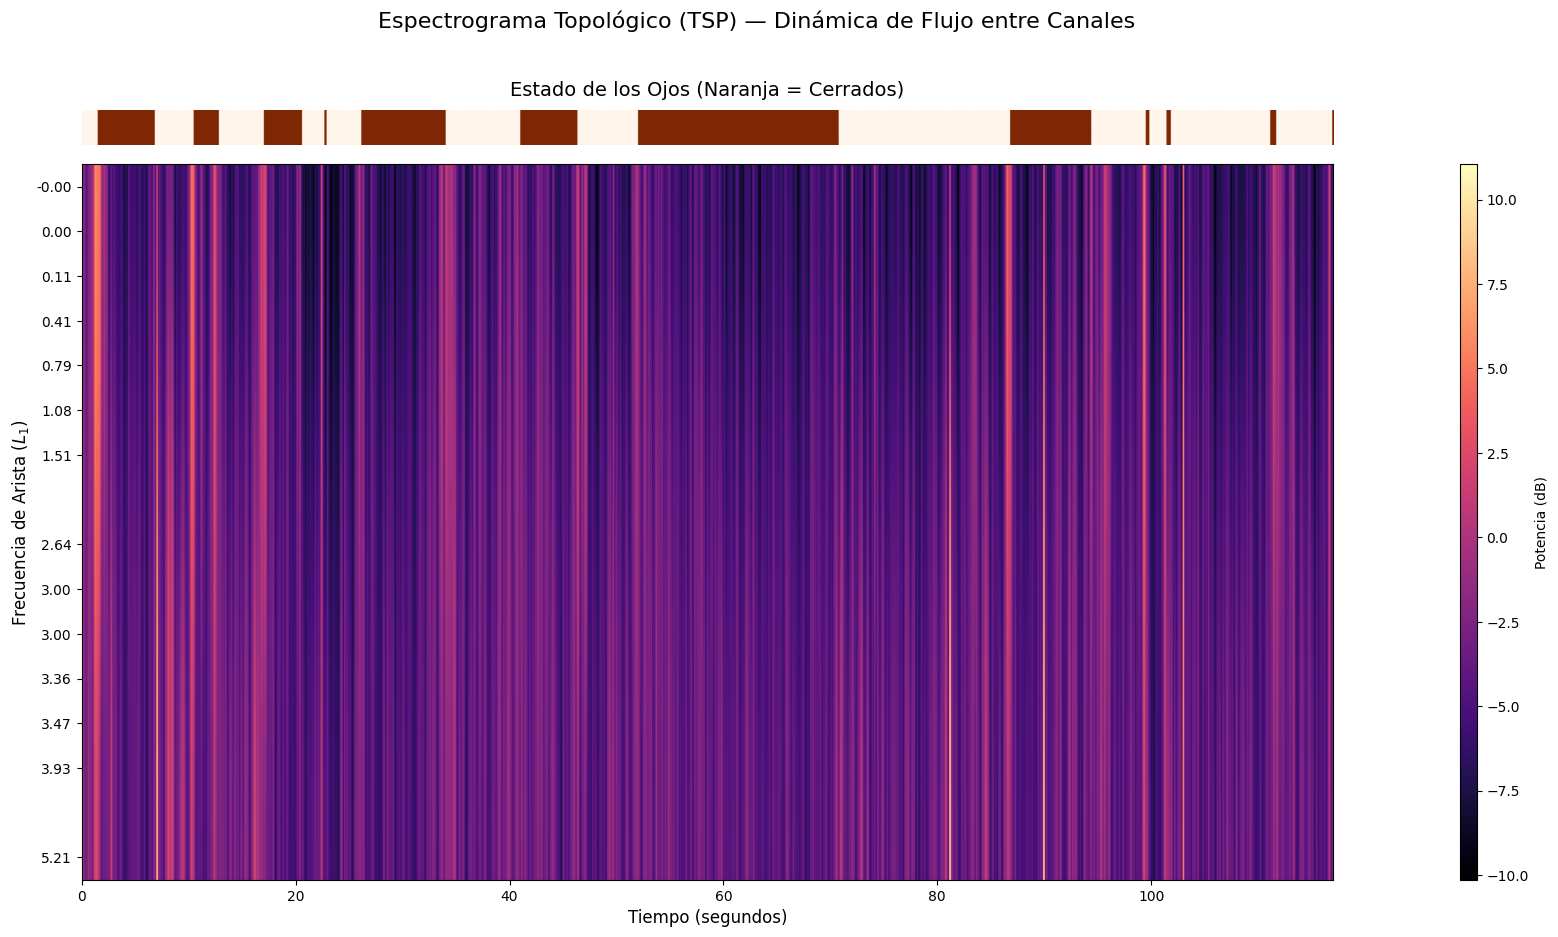

In [8]:
# --- Celda 4: Visualización TSP ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[0.05, 1], width_ratios=[1.5, 0.02], hspace=0.05)

# Label de Ojos (Mismo que GSP)
ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(labels_gsp[np.newaxis, :], aspect='auto', cmap='Oranges', 
           extent=[0, tiempo_total, 0, 1])
ax0.set_axis_off()
ax0.set_title('Estado de los Ojos (Naranja = Cerrados)', fontsize=14, pad=10)

# Espectrograma Topológico
ax1 = fig.add_subplot(gs[1, 0])
# extent ajustado para el número de aristas E
extent_tsp = [0, tiempo_total, E - 0.5, -0.5] 
im = ax1.imshow(tsp_spectrogram_log, aspect='auto', cmap='magma', extent=extent_tsp)

ax1.set_xlabel('Tiempo (segundos)', fontsize=12)
ax1.set_ylabel('Frecuencia de Arista ($L_1$)', fontsize=12)

# Configurar ticks del eje Y para no saturar si hay muchas aristas
yticks = np.linspace(0, E - 1, min(14, E), dtype=int)
ax1.set_yticks(yticks)
ax1.set_yticklabels([f'{evals_tsp[i]:.2f}' for i in yticks])

# Colorbar
cbar_ax = fig.add_subplot(gs[1, 1])
fig.colorbar(im, cax=cbar_ax, label='Potencia (dB)')

plt.suptitle('Espectrograma Topológico (TSP) — Dinámica de Flujo entre Canales', fontsize=16)
plt.tight_layout()
plt.show()

# Guardado y Verificacion

In [9]:
from pathlib import Path

save_dir = Path('./data/tf_representations')
save_dir.mkdir(parents=True, exist_ok=True)

# ── Guardar ────────────────────────────────────────────────────────────────

np.savez(save_dir / 'gsp.npz',
         spectrogram=graph_spectrogram_log,
         eigenvalues=evals,
         times=times_gsp,
         labels=labels_gsp,
         U=U,
         channels=np.array(CHANNELS))

np.savez(save_dir / 'tsp.npz',
         spectrogram=tsp_spectrogram_log,
         eigenvalues=evals_tsp,
         times=times_gsp,          # El eje temporal es idéntico al de GSP (14980)
         labels=labels_gsp,         # Mismo vector de estados (ojos abiertos/cerrados)
         U_1=U1,                   # Base de Fourier Topológica (E x E)
         edges=np.array(edges),     # Pares de electrodos indexados
         triangles=np.array(triangles), # Tríos de electrodos sincronizados
         A_bin=A_bin,              # Matriz de adyacencia binarizada usada para L1
         channels=np.array(CHANNELS))

# ── Verificar ──────────────────────────────────────────────────────────────
print(f"Archivos guardados en: {save_dir.resolve()}\n")

gsp_data = np.load(save_dir / 'gsp.npz', allow_pickle=True)
print("gsp.npz:")
print(f"  Claves          : {list(gsp_data.keys())}")
print(f"  Shape espectrograma: {gsp_data['spectrogram'].shape}  (modos × tiempo)")
print(f"  Shape eigenvalues  : {gsp_data['eigenvalues'].shape}")
print(f"  Shape times        : {gsp_data['times'].shape}")
print(f"  Shape labels       : {gsp_data['labels'].shape}")
print(f"  Shape U            : {gsp_data['U'].shape}")
print(f"  Clases             : {np.unique(gsp_data['labels'])}")

tsp_data = np.load(save_dir / 'tsp.npz', allow_pickle=True)
print("tsp.npz:")
print(f"  Claves             : {list(tsp_data.keys())}")
print(f"  Shape espectrograma: {tsp_data['spectrogram'].shape}  (modos de arista × tiempo)")
print(f"  Shape eigenvalues  : {tsp_data['eigenvalues'].shape}  (frecuencias de L1)")
print(f"  Shape times        : {tsp_data['times'].shape}")
print(f"  Shape labels       : {tsp_data['labels'].shape}")
print(f"  Shape U_1          : {tsp_data['U_1'].shape}")
print(f"  N° de Aristas (E)  : {len(tsp_data['edges'])}")
print(f"  N° de Triángulos(T): {len(tsp_data['triangles'])}")
print(f"  Clases             : {np.unique(tsp_data['labels'])}")

Archivos guardados en: /home/madmti/Work/UNIVERSIDAD/Proyecto_INF405/data/tf_representations

gsp.npz:
  Claves          : ['spectrogram', 'eigenvalues', 'times', 'labels', 'U', 'channels']
  Shape espectrograma: (14, 14980)  (modos × tiempo)
  Shape eigenvalues  : (14,)
  Shape times        : (14980,)
  Shape labels       : (14980,)
  Shape U            : (14, 14)
  Clases             : [0 1]
tsp.npz:
  Claves             : ['spectrogram', 'eigenvalues', 'times', 'labels', 'U_1', 'edges', 'triangles', 'A_bin', 'channels']
  Shape espectrograma: (16, 14980)  (modos de arista × tiempo)
  Shape eigenvalues  : (16,)  (frecuencias de L1)
  Shape times        : (14980,)
  Shape labels       : (14980,)
  Shape U_1          : (16, 16)
  N° de Aristas (E)  : 16
  N° de Triángulos(T): 1
  Clases             : [0 1]
